# University of London - ML Code - Computer Science Final Project

**BSc Computer Science**

**Subject: CM3070 Computer Science Final Project**

**Student: In Final Project report**

**Student Number: In Final Project report**

## Preparing the data

### Transforming the csv data to a numpy array

In [15]:
import numpy as np

usdYen_raw_data = np.genfromtxt("./data/currency-data/USD-JPY-DAILY.csv", skip_header=1, delimiter=";", usecols=1)

print("Length: ",len(usdYen_raw_data))
print("Data type: ",usdYen_raw_data.dtype)
print("Raw Data: ",usdYen_raw_data)

Length:  5000
Data type:  float64
Raw Data:  [154.71 155.21 155.81 ... 118.22 118.89 118.46]


As the currency data is from newer to older, the order should be inverted.

In [16]:
usdYen_raw_data = np.flip(usdYen_raw_data, axis=0)
print(usdYen_raw_data)

[118.46 118.89 118.22 ... 155.81 155.21 154.71]


### Computing the numer of samples for each data split

In [17]:
train_samples_number = len(usdYen_raw_data)
print("Number of train samples: ", train_samples_number)

Number of train samples:  5000


### Normalizing data

In [18]:
'''
mean = usdYen_raw_data[:train_samples_number].mean(axis=0)
usdYen_raw_data -= mean
std = usdYen_raw_data[:train_samples_number].std(axis=0)
usdYen_raw_data /= std

print(usdYen_raw_data)
'''


'\nmean = usdYen_raw_data[:train_samples_number].mean(axis=0)\nusdYen_raw_data -= mean\nstd = usdYen_raw_data[:train_samples_number].std(axis=0)\nusdYen_raw_data /= std\n\nprint(usdYen_raw_data)\n'

### Creating timeseries data

Based on the code provided in Chapter 10 (Deep Learning For Timeseries) of the book Deep Learning with Python by Francois Chollet [1].

In [19]:
from tensorflow import keras

# Parameters
sampling_rate = 1
sequence_length = 10 # Observations will go back 10 days
delay = sampling_rate * (sequence_length + 10 - 1) # target is 10 days weeks after the end of the sequence
batch_size = train_samples_number # small batch size to start

# train dataset
train_dataset = keras.utils.timeseries_dataset_from_array(
    usdYen_raw_data[:-delay],
    targets=usdYen_raw_data[delay:],
    sampling_rate=sampling_rate,
    sequence_length=sequence_length,
    batch_size=batch_size,
)

Checking that it works correctly

In [20]:
for inputs, targets in train_dataset:
    for i in range(inputs.shape[0]):
        print([float(x) for x in inputs[i]], float(targets[i]))

[118.46, 118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46] 118.15
[118.89, 118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96] 117.6
[118.22, 118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04] 118.01
[118.7, 119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15] 118.21
[119.34, 119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0] 117.74
[119.42, 119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28] 118.02
[119.01, 118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67] 117.92
[118.41, 117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85] 116.72
[117.6, 117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9] 116.28
[117.46, 116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54] 115.83
[116.96, 117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 117.54, 118.15] 116.09
[117.04, 117.15, 118.0, 118.28, 117.67, 117.85, 117.9, 1

Inspecting the output

In [21]:
import tensorflow as tf

data_inputs = []
data_outputs = []

for samples, targets in train_dataset:
    print("Samples: ", samples)
    print("Sample shape: ", samples.shape)
    print("Targets: ", targets)
    print("Targets shape: ", targets.shape)
    data_inputs = tf.make_ndarray(tf.make_tensor_proto(samples))
    data_outputs = tf.make_ndarray(tf.make_tensor_proto(targets))

Samples:  tf.Tensor(
[[118.46 118.89 118.22 ... 118.41 117.6  117.46]
 [118.89 118.22 118.7  ... 117.6  117.46 116.96]
 [118.22 118.7  119.34 ... 117.46 116.96 117.04]
 ...
 [153.67 154.11 153.06 ... 154.55 154.54 155.24]
 [154.11 153.06 153.4  ... 154.54 155.24 155.5 ]
 [153.06 153.4  154.14 ... 155.24 155.5  157.15]], shape=(4972, 10), dtype=float64)
Sample shape:  (4972, 10)
Targets:  tf.Tensor([118.15 117.6  118.01 ... 155.42 155.85 155.24], shape=(4972,), dtype=float64)
Targets shape:  (4972,)


2025-12-17 17:44:30.687219: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [22]:
print("----")
print("Input Data: ", len(data_inputs))
print("----")
print("Output Data: ", len(data_outputs))
print("----")

----
Input Data:  4972
----
Output Data:  4972
----


## Simple LSTM Model

In [23]:
from keras import models
from keras import layers

def build_lstm_model():
    model = models.Sequential()
    model.add(layers.LSTM(16, input_shape=(sequence_length, 1)))
    model.add(layers.Dense(1))
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

prototype_model = build_lstm_model()

### - PyGad

The code for the Genetic Algorithm is based on the code provided by the PyGAD library documentation [2].

Instance of the pygad.kerasga.KerasGA class

In [24]:
import pygad.kerasga

keras_ga = pygad.kerasga.KerasGA(model=prototype_model, num_solutions=20)

Fitness function

In [25]:
def fitness_function(ga_instance, solution, solution_index):
    global data_inputs, data_outputs, keras_ga, prototype_model
    predictions = pygad.kerasga.predict(model=prototype_model, solution=solution, data=data_inputs)
    mae = keras.losses.MeanAbsoluteError()
    absolute_error = mae(data_outputs, predictions).numpy() + + 0.00000001
    solution_fitness = 20 / absolute_error
    return solution_fitness

Track GA

In [26]:
def on_generation(ga_instance):
    print(f"Generation = {ga_instance.generations_completed}")
    print(f"Fitness    = {ga_instance.best_solution()[1]}")

Create instance of the pygad.GA class

In [27]:
num_generations = 50
num_parents_mating = 10
initial_population = keras_ga.population_weights

ga_instance = pygad.GA(num_generations=num_generations,
                       num_parents_mating=num_parents_mating,
                       initial_population=initial_population,
                       fitness_func=fitness_function,
                       on_generation=on_generation)

In [28]:
ga_instance.run()

Generation = 1
Fitness    = 0.18411977589130402
Generation = 2
Fitness    = 0.18411977589130402
Generation = 3
Fitness    = 0.18454298377037048
Generation = 4
Fitness    = 0.18454298377037048
Generation = 5
Fitness    = 0.18454298377037048
Generation = 6
Fitness    = 0.18689562380313873
Generation = 7
Fitness    = 0.18724359571933746
Generation = 8
Fitness    = 0.18916669487953186
Generation = 9
Fitness    = 0.18916669487953186
Generation = 10
Fitness    = 0.19024969637393951
Generation = 11
Fitness    = 0.19024969637393951
Generation = 12
Fitness    = 0.19156892597675323
Generation = 13
Fitness    = 0.1933726668357849
Generation = 14
Fitness    = 0.19462250173091888
Generation = 15
Fitness    = 0.19462250173091888
Generation = 16
Fitness    = 0.19462250173091888
Generation = 17
Fitness    = 0.19691428542137146
Generation = 18
Fitness    = 0.1978047490119934
Generation = 19
Fitness    = 0.1978047490119934
Generation = 20
Fitness    = 0.19938243925571442
Generation = 21
Fitness    = 0.1

/Users/studentcode/Documents/UOL/Semester 6/Computer Science Final Project/ML - CM3070 - In Final Project report - University of London/.venv/lib/python3.13/site-packages/pygad/visualize/plot.py:120: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  matplt.legend()


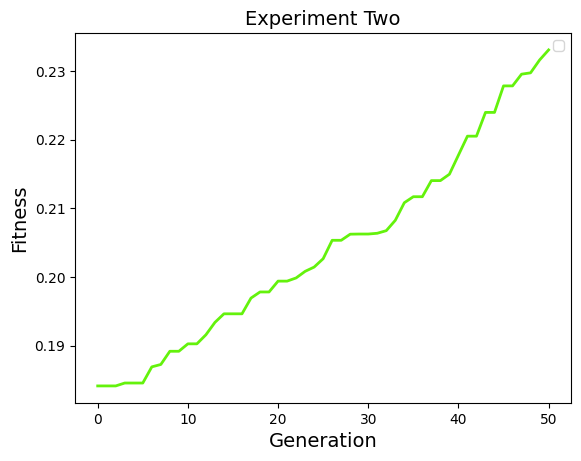

Figure(640x480)


In [29]:
print(ga_instance.plot_fitness(title="Experiment Two", linewidth=2))

## About the code

The timeseries data code is based on the code shown in the chapter of the book Deep Learning with Python.

The Genetic Algorithm code is based on the code shown in the docs of the PyGAD library.

## References

1- Francois Chollet. 2021. Deep Learning with Python, Second Edition. Chapter 10, Deep learning for timeseries, Preparing the data. Retrieved from https://learning.oreilly.com/library/view/deep-learning-with/9781617296864/Text/10.htm#heading_id_5

2- PyGAD. pygad.kerasga Module. Retrieved from https://pygad.readthedocs.io/en/latest/kerasga.html#